## **ESTO ES UN EJEMPLO DE MLP RNA**

In [379]:
%pip install numpy pandas scikit-learn tensorflow matplotlib

Note: you may need to restart the kernel to use updated packages.


**Añadimos las librerías necesarias y cargamos el modelo de scikit-learn**

In [380]:
import sklearn
from sklearn.model_selection import KFold, train_test_split
import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.datasets import load_digits
digits = load_digits()

**Preparamos la función RNA**

In [381]:
# Creamos MLP
def build_model():
    # MLP es secuencial
    model = Sequential()

    # Añadimos capas densas (fully connected)
    # input_dim es 64 porque tenemos ejemplos de 8x8 píxeles
    # función de activación ReLU para las capas ocultas
    model.add(Dense(64, input_dim=64, activation='relu')) 
    model.add(Dense(32, activation='relu'))

    # función de activación softmax para clasificación multiclase
    model.add(Dense(10, activation='softmax'))
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

**Preparamos los datos, los preprocesamos y dividimos**

In [382]:
X = digits.data
Y = digits.target

print("Valores nulos:", np.isnan(X).sum())

# Los píxeles están entre 0 y 16, por lo que se normalizan dividiendo entre 16
X = digits.data / 16.0

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

y_train = to_categorical(y_train, num_classes=10)
y_val = to_categorical(y_val, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

Valores nulos: 0


# **Entrenamos al modelo**

In [383]:
model = build_model()
print("-- LETS GO --")
print("-------------")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))

-- LETS GO --
-------------
Epoch 1/20


/home/ivix/Escritorio/practica_MLP_RNA/.venv/lib/python3.14/site-packages/keras/src/layers/core/dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3821 - loss: 2.1345 - val_accuracy: 0.6458 - val_loss: 1.9148
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7206 - loss: 1.6733 - val_accuracy: 0.8507 - val_loss: 1.3447
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8590 - loss: 1.0682 - val_accuracy: 0.8854 - val_loss: 0.7618
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8947 - loss: 0.6346 - val_accuracy: 0.9410 - val_loss: 0.4776
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9138 - loss: 0.4369 - val_accuracy: 0.9514 - val_loss: 0.3496
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9347 - loss: 0.3341 - val_accuracy: 0.9549 - val_loss: 0.2806
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9426 - loss: 0.2707 - val_accuracy: 0.9618 - val_loss: 0.2372
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9469 - loss: 0.2270 - val_accuracy: 0.9653 - val_loss: 0.2077
Ep

**Comprobamos eficacia con validación**

In [384]:
print("-- VALIDACIÓN: --")
print("-----------------")
val_loss, val_acc = model.evaluate(X_val, y_val)


-- VALIDACIÓN: --
-----------------
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9757 - loss: 0.1068 


**Comprobamos eficacia con test**

In [385]:
print("-- TEST: --")
print("-----------")
test_loss, test_acc = model.evaluate(X_test, y_test)

-- TEST: --
-----------
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9722 - loss: 0.1049


# **COMPARACIÓN GRÁFICA**
**Comparamos gráficamente para ver como aprender la red y comprobar si hay overfitting**

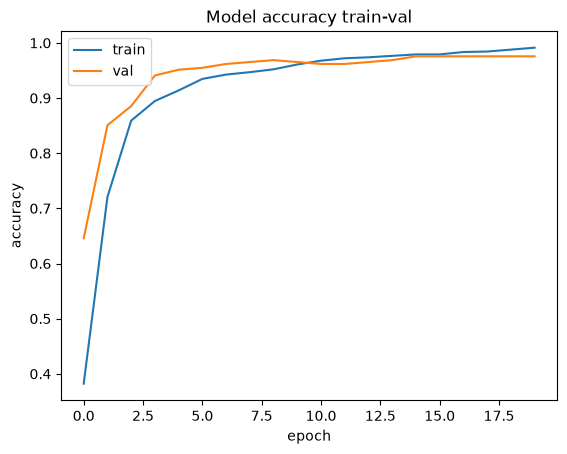

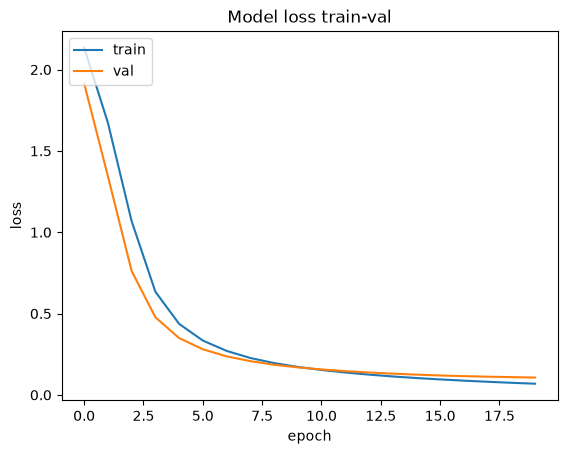

In [386]:
# Evolución de accuracy train-val
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy train-val')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Evolución de loss train-val
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss train-val')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Cómo se puede apreciar, el modelo está muy bien entrenado y no hay overfitting.

# **Matriz de confusión**
Nos muestra que imágenes se han clasificado correctamente y cuáles se han clasificado en otro lugar. Por ejemplo, podemos ver que **los números 2, 4, 5 y 7 los detecta a la perfección**. También se puede apreciar que el modelo **ha confundido 3 veces el número 8 con el número 1** (se aprecian más confusiones, como del 0 con el 4, del 1 con el 5, del 1 con el 6 y del 1 con el 8, del 3 con el 5, del 6 con el 8, del 9 con el 7).

In [387]:
# Predecir las probabilidades en el conjunto de test
y_pred_probs = model.predict(X_test)

# Extraer la clase predicha con mayor probabilidad
class_testPred = np.argmax(y_pred_probs, axis=1)

# Extraer las clases reales de y_test
y_test_classes = np.argmax(y_test, axis=1)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test_classes, class_testPred)
print("Matriz de confusión:\n", cm)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Matriz de confusión:
 [[35  0  0  0  1  0  0  0  0  0]
 [ 0 33  0  0  0  1  1  0  1  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 36  0  1  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 35  0  1  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  3  0  0  0  0  0  0 32  0]
 [ 0  0  0  0  0  0  0  1  0 35]]
